In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.attractor_networks import ToroidZhang1996
import os

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

Ran warm up for 1385 steps


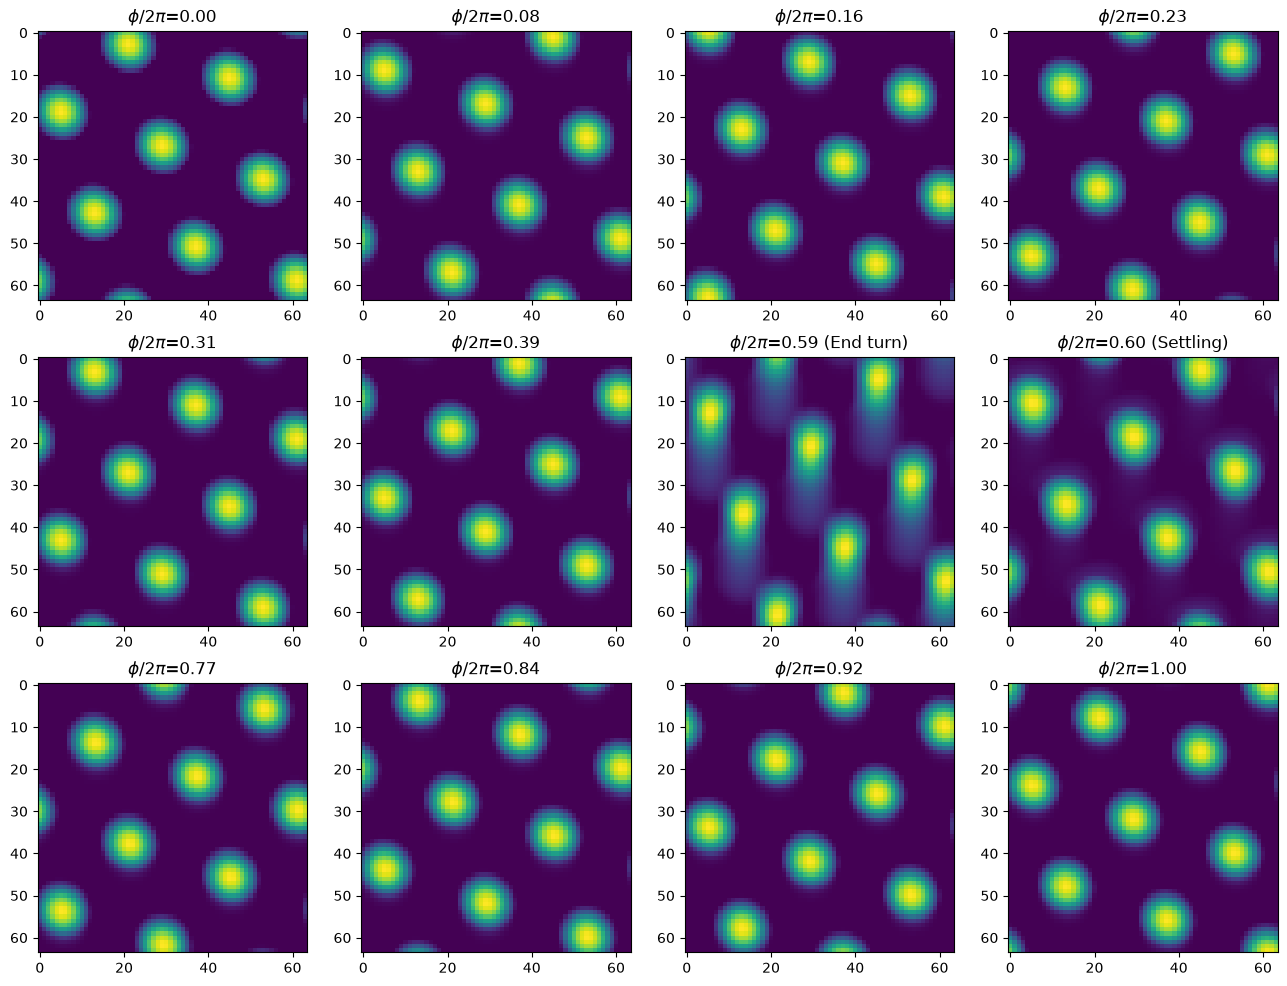

In [2]:
## Simulation parameters:
n_min_plots = 10
dt = 0.5e-3
n = 64

net = ToroidZhang1996(n=n, dt=dt, periodicity=18, revolutions=(2,1))
net.warm_up()
ncols = np.int64(np.ceil(np.sqrt(n_min_plots)))
nrows = np.int64(np.ceil(n_min_plots / ncols))
n_plots = nrows * ncols
fig, ax = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
ax = ax.flatten()
phi = 0
omega = 5
omega_max = 50
duration = int(0.02 / dt)
n_steps = int((2 * np.pi - omega_max * duration * dt) / omega / dt) + duration
records = np.linspace(0, n_steps - 1, n_plots, dtype=int)
plot_counter = 0
time = 0


for step_iter in range(n_steps):
    if step_iter - n_steps // 2 == duration:
        net.step(omega_max, 0)
        ax[plot_counter].imshow(net.s)
        ax[plot_counter].set_title(f"$\\phi/2\\pi$={phi/(2*np.pi):.2f} (End turn)")
        plot_counter += 1
    elif step_iter - n_steps // 2 == 2 * duration:
        net.step(omega_max, 0)
        ax[plot_counter].imshow(net.s)
        ax[plot_counter].set_title(f"$\\phi/2\\pi$={phi/(2*np.pi):.2f} (Settling)")
        plot_counter += 1
    elif step_iter == records[plot_counter]:
        ax[plot_counter].imshow(net.s)
        ax[plot_counter].set_title(f"$\\phi/2\\pi$={phi/(2*np.pi):.2f}")
        plot_counter += 1
    if 0 <= (step_iter - n_steps // 2) < duration:
        net.step(omega_max, 0)
        phi += omega_max * dt
    else:
        net.step(omega, 0)
        phi += omega * dt
    time += dt

In [ ]:
T = 400
dt = 0.5e-3
n = 64
net = ToroidZhang1996(n=n, dt=dt, periodicity=18, revolutions=2.5)
net.warm_up()
bat_flight = generate_bat_flight(T=T, dt=dt)
n_steps = bat_flight["pos"].shape[0]
recorded_cells = list(np.random.randint(0, n - 1, size=(9, 2)))

recording = net.run_simulation(bat_flight["dir_vel"])

In [ ]:
from grid_cells.plot_tools import activity_map

cell_index = 0

direction_activity_map, counts, direction_edges = activity_map(
    bat_flight["dir_torus"], recording["cell_recording"][:, cell_index], nbins=25
)
fig, ax = plt.subplots()
ax.imshow(
    direction_activity_map,
    extent=(
        direction_edges[0][0],
        direction_edges[0][-1],
        direction_edges[1][0],
        direction_edges[1][-1],
    ),
    interpolation="bilinear",
    origin="lower",
)
ax.set_xlabel("Azimuth")
ax.set_ylabel("Pitch")
ax.set_xticks(np.arange(0, 2.5, 0.5) * np.pi)
ax.set_xticklabels([r"0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"2$\pi$"])
ax.set_yticks(np.arange(0, 2.5, 0.5) * np.pi)
ax.set_yticklabels([r"0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"2$\pi$"])
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_3d_direction_grid_aperiodic.png"))

In [ ]:
import numpy as np

pos = bat_flight["pos"].astype(np.float32)
rate = recording["cell_recording"][:, 0].astype(np.float64)

# Only positive-rate samples can contribute
valid = rate > 0
pos = pos[valid]
rate = rate[valid]

# Probability of selecting a sample proportional to firing rate
p = rate / rate.sum()

rng = np.random.default_rng(42)

n_pairs = 100_000_000
chunk = 500_000

bins = 25
dist_hist = np.zeros(bins, dtype=np.int64)
weighted_hist = np.zeros(bins, dtype=np.float64)

# Determine sensible distance range
pos_min = pos.min(axis=0)
pos_max = pos.max(axis=0)
max_dist = np.linalg.norm(pos_max - pos_min)

edges = np.linspace(0.5, max_dist, bins + 1)

for start in range(0, n_pairs, chunk):
    n = min(chunk, n_pairs - start)

    i = rng.choice(len(pos), size=n)
    j = rng.choice(len(pos), size=n)

    d = np.linalg.norm(pos[i] - pos[j], axis=1)

    dist_hist += np.histogram(d, bins=edges)[0]
    weighted_hist += np.histogram(d, bins=edges, weights=rate[i] * rate[j])[0]

# Normalize to a PDF
dist_pdf = dist_hist / (dist_hist.sum() * np.diff(edges))
weighted_dist_pdf = weighted_hist / (weighted_hist.sum() * np.diff(edges))
centers = (edges[:-1] + edges[1:]) / 2

In [ ]:
fig, ax = plt.subplots(nrows=2, height_ratios=(4, 1), sharex=True)
up, down = ax[0], ax[1]
up.stairs(weighted_dist_pdf, edges, label="Average Distance", linestyle="-")
up.stairs(
    weighted_dist_pdf,
    edges,
    label="Neural Activity Weighted Average Distance",
    linestyle="--",
)
up.set_ylabel("Normalised Density")
up.legend(loc="best")
ratio = weighted_dist_pdf / (dist_pdf + 1e-6)
down.set_xlabel("Distance [m]")
down.stairs(ratio, edges)
down.set_xlim(edges[0], edges[-1])
down.set_ylim(np.min(ratio) * 0.9, np.max(ratio) * 1.1)
down.axhline(y=1, color="grey", linestyle="dotted")
down.set_ylabel("Ratio")

In [ ]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize

n_steps = bat_flight["pos"].shape[0]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

speed_mask = np.linalg.norm(bat_flight["vel"], axis=-1) > 1.2

pos = bat_flight["pos"][: int(n_steps * 0.4)]

cell_index = 1
activity = recording["cell_recording"][: len(pos), cell_index]

segments = np.stack([pos[:-1], pos[1:]], axis=1)
norm = Normalize(vmin=activity.min(), vmax=activity.max())

line_collection = Line3DCollection(
    segments,
    cmap="viridis",
    norm=norm,
    linewidth=0.8,
    alpha=0.8,
)
line_collection.set_array(activity[:-1])
ax.add_collection3d(line_collection)

fig.colorbar(
    line_collection,
    ax=ax,
    pad=0.1,
    label=f"Neural activity (Cell {cell_index})",
)

ax.scatter(pos[0, 0], pos[0, 1], pos[0, 2], color="green", s=40, label="start")
ax.scatter(pos[-1, 0], pos[-1, 1], pos[-1, 2], color="red", s=40, label="end")

ax.set_title("Bat trajectory")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_3d_trajectory_activity.png"))